In [4]:
import sqlite3

# Connect to SQLite database (creates file if it doesn't exist)
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Create new, realistic sales table
cursor.execute('''
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    date TEXT,
    product_id INTEGER,
    product_name TEXT,
    category TEXT,
    quantity INTEGER,
    price REAL,
    region TEXT,
    salesperson TEXT
)
''')

# Sample business-like sales data
sales_data = [
    ("2025-04-28", 101, "iPhone 13", "Electronics", 2, 799.99, "North", "Alice"),
    ("2025-04-28", 102, "Samsung TV", "Electronics", 1, 499.99, "South", "Bob"),
    ("2025-04-29", 103, "Dell Laptop", "Computers", 3, 899.50, "East", "Alice"),
    ("2025-04-30", 101, "iPhone 13", "Electronics", 1, 799.99, "North", "Charlie"),
    ("2025-04-30", 104, "Milk", "Grocery", 10, 2.50, "West", "Diana"),
    ("2025-05-01", 105, "Bread", "Grocery", 20, 1.80, "West", "Diana"),
    ("2025-05-01", 102, "Samsung TV", "Electronics", 1, 499.99, "South", "Bob"),
    ("2025-05-01", 106, "HP Printer", "Computers", 2, 149.75, "East", "Alice")
]

# Insert the sample data
cursor.executemany('''
INSERT INTO sales (date, product_id, product_name, category, quantity, price, region, salesperson)
VALUES (?, ?, ?, ?, ?, ?, ?, ?)
''', sales_data)

# Save and close
conn.commit()
conn.close()

print("sales_data.db created with sample business data!")


sales_data.db created with sample business data!


📊 Revenue & Quantity by Product:
  product_name  total_quantity  total_revenue
0  Dell Laptop               9        8095.50
1    iPhone 13               9        7199.91
2   Samsung TV               6        2999.94
3   HP Printer               6         898.50
4        Bread              60         108.00
5         Milk              30          75.00

📈 Revenue by Category:
      category   revenue
0  Electronics  10199.85
1    Computers   8994.00
2      Grocery    183.00

🏅 Top Salesperson by Revenue:
  salesperson   revenue
0       Alice  13793.94
1         Bob   2999.94
2     Charlie   2399.97
3       Diana    183.00


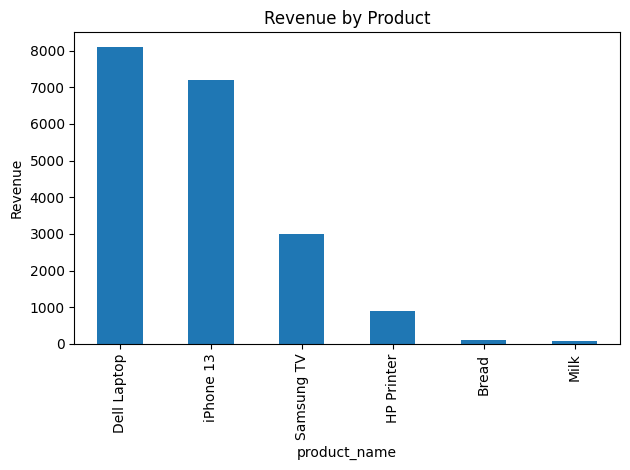

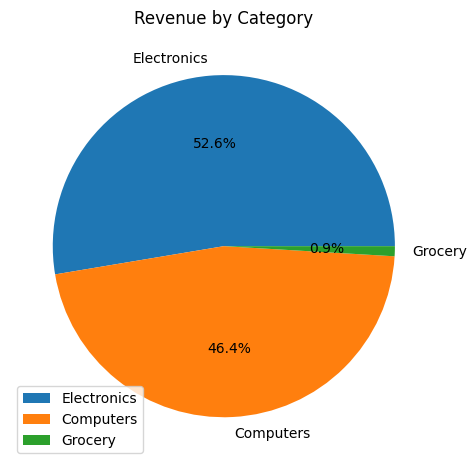

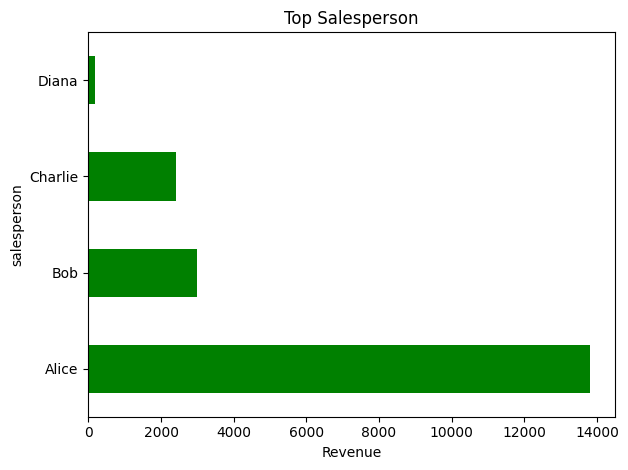

In [6]:

import pandas as pd
import matplotlib.pyplot as plt

# Connect to the database
conn = sqlite3.connect("sales_data.db")

#Revenue and Quantity by Product
query = """
SELECT
    product_name,
    SUM(quantity) AS total_quantity,
    ROUND(SUM(quantity * price), 2) AS total_revenue
FROM sales
GROUP BY product_name
ORDER BY total_revenue DESC
"""

df = pd.read_sql_query(query, conn)
print("📊 Revenue & Quantity by Product:")
print(df)

# Revenue by Category
category_query = """
SELECT
    category,
    ROUND(SUM(quantity * price), 2) AS revenue
FROM sales
GROUP BY category
ORDER BY revenue DESC
"""

category_df = pd.read_sql_query(category_query, conn)
print("\n📈 Revenue by Category:")
print(category_df)

#  Top Salesperson
salesperson_query = """
SELECT
    salesperson,
    ROUND(SUM(quantity * price), 2) AS revenue
FROM sales
GROUP BY salesperson
ORDER BY revenue DESC
"""

salesperson_df = pd.read_sql_query(salesperson_query, conn)
print("\n🏅 Top Salesperson by Revenue:")
print(salesperson_df)

conn.close()

# Save data as CSV
df.to_csv("product_sales_summary.csv", index=False)
category_df.to_csv("category_revenue.csv", index=False)
salesperson_df.to_csv("salesperson_ranking.csv", index=False)

# Plot 1: Revenue by Product
df.plot(kind='bar', x='product_name', y='total_revenue', title='Revenue by Product', legend=False)
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("product_revenue_chart.png")
plt.show()

# Plot 2: Revenue by Category
category_df.plot(kind='pie', y='revenue', labels=category_df['category'], autopct='%1.1f%%', title='Revenue by Category')
plt.ylabel("")
plt.tight_layout()
plt.savefig("category_revenue_pie.png")
plt.show()

# Plot 3: Salesperson Ranking
salesperson_df.plot(kind='barh', x='salesperson', y='revenue', title='Top Salesperson', color='green', legend=False)
plt.xlabel("Revenue")
plt.tight_layout()
plt.savefig("salesperson_ranking.png")
plt.show()
